# Gray Gas Fundamentals

We explore the mechanics of the `GrayLongwaveRadiation` component in `climt`/`sympl`
and understand how radiative transfer works in a gray atmosphere.

Everything here is **instantaneous diagnostics**. We focus on:
1. **Optical Depth Profiles**: How changing the vertical distribution of absorbers affects the column.
2. **The Heating Rate**: Understanding where the atmosphere heats and cools via $\mathcal{H}(\tau) = I^+ + I^- - 2B$.
3. **Sensitivity to Optical Depth**: How the heating profile changes between thin and thick atmospheres.

In [12]:
from climt import (
    Frierson06LongwaveOpticalDepth, GrayLongwaveRadiation,
    get_default_state)
import numpy as np
import matplotlib.pyplot as plt

sigma = 5.67e-8  # Stefan-Boltzmann constant (W/m^2/K^4)

## How `climt` solves the Two-Stream Equations

Let's look at how the gray radiation is actually computed.
The code below is extracted from `climt/_components/radiation.py` ([Documentation](https://climt.readthedocs.io/en/latest/generated/climt.Frierson06LongwaveOpticalDepth.html#climt.Frierson06LongwaveOpticalDepth))

$$\tau = \tau_0[1 - (f_l\frac{p}{p_s} + (1-f_l)(\frac{p}{p_s})^4)]$$

The constant $f_l$ determines how much of the variation of $\tau$ with pressure is linear rather than quartic. Default is 0.1 as in Frierson guy paper in 2006.

The core kernel is:

```python
for k in range(nlev_plus_1):
    sigma = p_interface[k, i] / ps_val # sigma = p/p_s (normalised pressure)
    tau[k, i] = tau_0 * (1.0 - (fl * sigma + (1.0 - fl) * sigma**4))
```

At surface, $\sigma = 1$ and so $\tau = 0$ . At TOA, $\sigma = 0$ and so $\tau = \tau_0$

> **Note**: the code uses $\sigma^4$ for the non-linear term, not $\sigma^2$ as in the
> original Frierson (2006) formula. This concentrates more optical depth near the surface
> when $f < 1$, mimicking the strong pressure dependence of water vapour absorption.

### The Two-Stream Radiative Transfer Kernel

The heart of the model is `_gray_lw_kernel_np`. It solves the two-stream equations by
**moving through the column layer by layer**, applying Beer's law at each step.

```python
def _gray_lw_kernel_np(T, p_interface, T_surface, tau, sigma):
    nlev, ncol = T.shape
    upward_flux   = np.zeros((nlev + 1, ncol)) # fluxes on interface levels
    downward_flux = np.zeros((nlev + 1, ncol))

    T4 = sigma * T**4   # sigma here is the Stefan-Boltzmann constant
                        # T4[k] = sigma_SB * T[k]^4 = B(k), the Planck emission
```

**Upward flux** - moving from the surface (index 0) to the TOA (index `nlev`):
```python
    upward_flux[0, i] = sigma * T_surface[i]**4 # surface boundary: I+(0) = sigma * Tg^4

    for k in range(1, nlev + 1):
        dtau  = tau[k, i] - tau[k - 1, i] # optical thickness of layer k
        trans = np.exp(-dtau) # transmissivity of the layer

        upward_flux[k, i] = (
            upward_flux[k - 1, i] * trans # flux from below, attenuated
            + T4[k - 1, i] * (1.0 - trans) # + emission from this layer
        )
```

This is the **discrete version** of the integral solution:
$$I^+(\tau) = I^+(0)\, e^{-\tau} + \int_0^\tau B(\tau')\, e^{-(\tau - \tau')}\, d\tau'$$
Each layer transmits a fraction $e^{-\Delta\tau}$ of the incoming flux and adds its own
thermal emission $B \cdot (1 - e^{-\Delta\tau})$. The factor $(1 - e^{-\Delta\tau})$ is the
**emissivity** of the layer - by Kirchhoff's law, it equals the absorptivity.

**Downward flux** - moving from the TOA (index `nlev`) to the surface (index 0):
```python
    downward_flux[nlev, i] = 0.0 # TOA boundary: I-(tau_inf) = 0 (no IR from space)

    for k in range(nlev - 1, -1, -1):
        dtau  = tau[k + 1, i] - tau[k, i]
        trans = np.exp(-dtau)

        downward_flux[k, i] = (
            downward_flux[k + 1, i] * trans # flux from above, attenuated
            + T4[k, i] * (1.0 - trans) # + emission from this layer
        )
```

This is the discrete version of:
$$I^-(\tau) = \int_\tau^{\tau_\infty} B(\tau')\, e^{-(\tau' - \tau)}\, d\tau'$$

### Computing the Heating Rate (Temperature Tendency)

Once the fluxes are known, the heating rate follows from the **net flux divergence**.
The net flux is $F_{net} = I^+ - I^-$, and the heating rate in K/s is:

```python
    net_lw_flux = upward_flux - downward_flux

    lw_temperature_tendency = (
        g / cpd                                        # converts flux divergence to K/s
        * (net_lw_flux[1:, :] - net_lw_flux[:-1, :])   # Delta(F_net) across each layer
        / (p_int[1:, :] - p_int[:-1, :])               # Delta(p) = layer mass (Pa)
    )
```

This is the hydrostatic form of $\partial T/\partial t = -(g/c_p) \cdot \partial F_{net}/\partial p$.
The factor $g/c_p$ converts from flux divergence per unit pressure ($W/m^2/Pa$) to a temperature
tendency (K/s). Note the sign: if $F_{net}$ *decreases* going up (i.e., the layer absorbs more
than it emits), the layer warms.

### Summary of the Vertical Grid

| Quantity | Lives on | Array size | Index 0 | Index N |
|----------|----------|------------|---------|---------|
| $\tau$, $I^+$, $I^-$, $F_{net}$ | Interface levels | `nlev + 1` | TOA | Surface |
| $T$, $B$, $\partial T/\partial t$ | Mid-levels | `nlev` | TOA | Surface |

Fluxes are defined on `nlev + 1` interface levels (layer boundaries), while temperatures and
heating rates are defined on `nlev` mid-levels (layer centres). When comparing fluxes to $B$,
we need to interpolate one grid to the other.

## Defining Optical Depth Profiles

As described above, the `Frierson06LongwaveOpticalDepth` component computes $\tau$ on interface
levels using a blend of linear and quartic dependencies on normalised pressure $\sigma = p/p_s$:
$$\tau(\sigma) = \tau_{\infty} \left[1 - f\, \sigma - (1-f)\, \sigma^4 \right]$$
where $f$ is the `linear_optical_depth_parameter` and $\tau_\infty$ is `longwave_optical_depth_at_equator`.

When $f = 1$ (purely linear), $\tau$ varies linearly with pressure.
When $f = 0$ (purely quartic), optical depth is concentrated near the surface -
mimicking the strong pressure/temperature dependence of water vapour absorption.

Let's visualise the profiles for different choices.

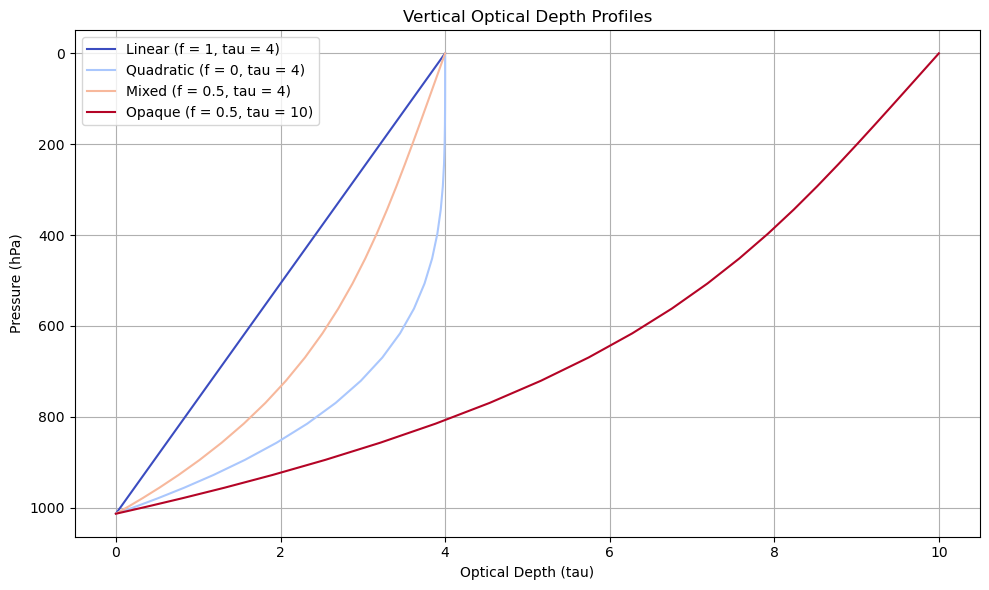

In [13]:
diagnostic = Frierson06LongwaveOpticalDepth()
radiation = GrayLongwaveRadiation()
state = get_default_state([radiation, diagnostic])

p_interface = state['air_pressure_on_interface_levels']

configs = [
    {'name': 'Linear (f = 1, tau = 4)', 'f': 1.0, 'tau0': 4.0},
    {'name': 'Quadratic (f = 0, tau = 4)', 'f': 0.0, 'tau0': 4.0},
    {'name': 'Mixed (f = 0.5, tau = 4)', 'f': 0.5, 'tau0': 4.0},
    {'name': 'Opaque (f = 0.5, tau = 10)', 'f': 0.5, 'tau0': 10.0}
]

cmap = plt.get_cmap('coolwarm')

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for i, cfg in enumerate(configs):
    diag = Frierson06LongwaveOpticalDepth(
        linear_optical_depth_parameter=cfg['f'],
        longwave_optical_depth_at_equator=cfg['tau0']
    )
    state.update(diag(state))
    tau = state['longwave_optical_depth_on_interface_levels']
    ax.plot(
        tau.values.flatten(),
        p_interface.values.flatten() / 100,
        label=cfg['name'],
        color=cmap(i / (len(configs) - 1))
    )

ax.set_xlabel('Optical Depth (tau)')
ax.set_ylabel('Pressure (hPa)')
ax.invert_yaxis()
ax.legend()
plt.grid()
ax.set_title('Vertical Optical Depth Profiles')
plt.tight_layout()

## The Heating Rate: Where Does the Atmosphere Heat and Cool?

The local radiative heating rate is:
$$\mathcal{H}(\tau) = I^+(\tau) + I^-(\tau) - 2B(\tau)$$
A layer heats by absorbing the ambient radiation field ($I^+ + I^-$) and cools by emitting
both upward and downward ($2B = 2\sigma T^4$).

In an isothermal atmosphere, $\mathcal{H} \approx 0$ everywhere (trivially balanced). A much more
instructive experiment is to start with a **realistic lapse rate** and see which layers are out
of radiative balance - this shows *why* the atmosphere evolves toward equilibrium.

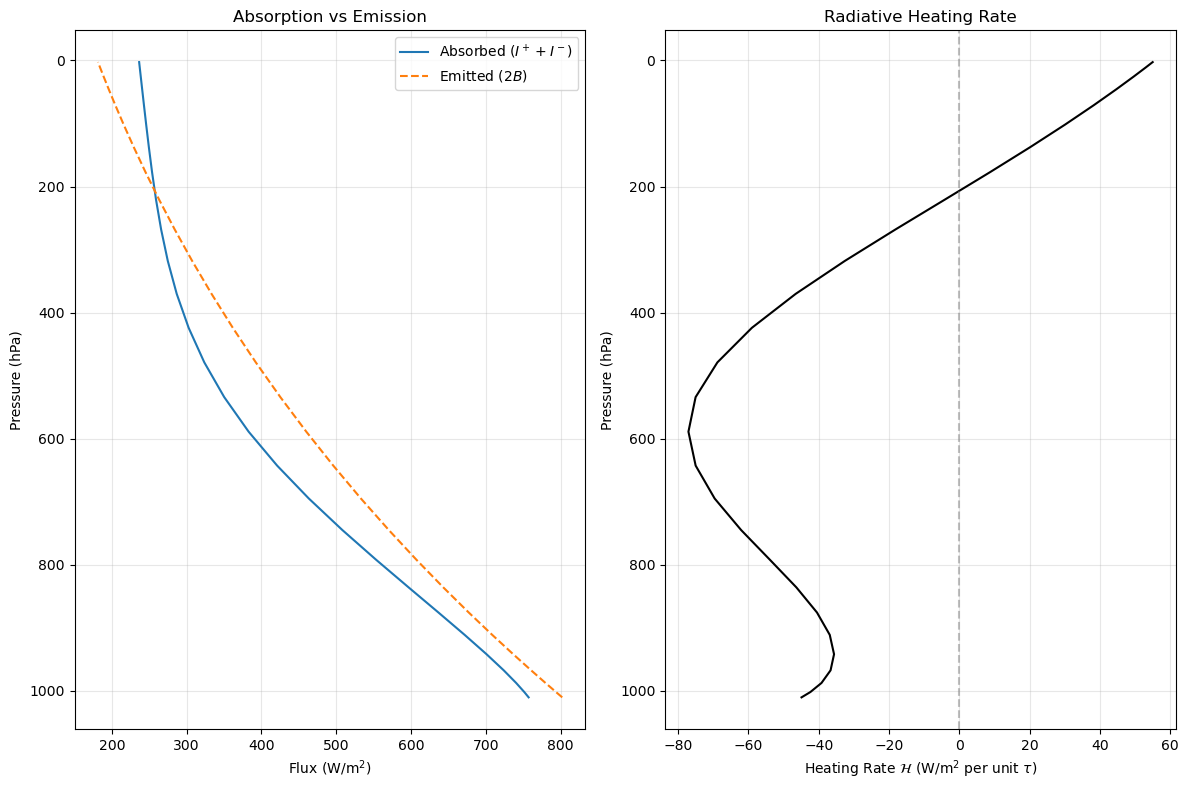

In [14]:
# Set up a column with a tropospheric lapse rate and a warm surface
diagnostic = Frierson06LongwaveOpticalDepth(longwave_optical_depth_at_equator=4.0)
radiation = GrayLongwaveRadiation()
state = get_default_state([radiation, diagnostic])

# Impose a linear temperature profile from 290 K (surface) to 200 K (TOA)
p_mid = state['air_pressure'].values.flatten()
p_sfc = p_mid[-1]
p_top = p_mid[0]
T_sfc = 290.0
T_top = 200.0
T_profile = T_top + (T_sfc - T_top) * (p_mid - p_top) / (p_sfc - p_top)

state['air_temperature'].values[:, 0, 0] = T_profile[::-1]
state['surface_temperature'][:] = T_sfc

# Compute optical depth and radiation
state.update(diagnostic(state))
tendencies, diag_lw = radiation(state)
state.update(diag_lw)

# Retrieve fluxes on interface levels and interpolate to mid-levels
I_up = state['upwelling_longwave_flux_in_air'].values[:, 0, 0]
I_down = state['downwelling_longwave_flux_in_air'].values[:, 0, 0]
I_up_mid = 0.5 * (I_up[:-1] + I_up[1:])
I_down_mid = 0.5 * (I_down[:-1] + I_down[1:])

T = state['air_temperature'].values.flatten()
B = sigma * T**4

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# Left panel: (I+) + (I-) vs 2B
ax = axes[0]
ax.plot(I_up_mid + I_down_mid, p_mid / 100, label=r'Absorbed ($I^+ + I^-$)')
ax.plot(2 * B, p_mid / 100, '--', label=r'Emitted ($2B$)')
ax.invert_yaxis()
ax.set_xlabel('Flux (W/m$^2$)')
ax.set_ylabel('Pressure (hPa)')
ax.set_title('Absorption vs Emission')
ax.legend()
ax.grid(True, alpha=0.3)

# Right panel: heating rate H = (I+) + (I-) - 2B
ax = axes[1]
H = I_up_mid + I_down_mid - 2 * B
ax.plot(H, p_mid / 100, 'k-')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.invert_yaxis()
ax.set_xlabel(r'Heating Rate $\mathcal{H}$ (W/m$^2$ per unit $\tau$)')
ax.set_ylabel('Pressure (hPa)')
ax.set_title('Radiative Heating Rate')
ax.grid(True, alpha=0.3)

plt.tight_layout()

## How Optical Depth Changes the Heating Profile

Let's compare heating rate profiles for thin ($\tau_\infty = 0.5$), moderate ($\tau_\infty = 4$),
and thick ($\tau_\infty = 15$) atmospheres, all starting from the same lapse rate profile.

In a thin atmosphere, the heating/cooling is dominated by the boundaries (surface and space).
In a thick atmosphere, only nearby layers matter - radiation becomes a local, diffusive process.

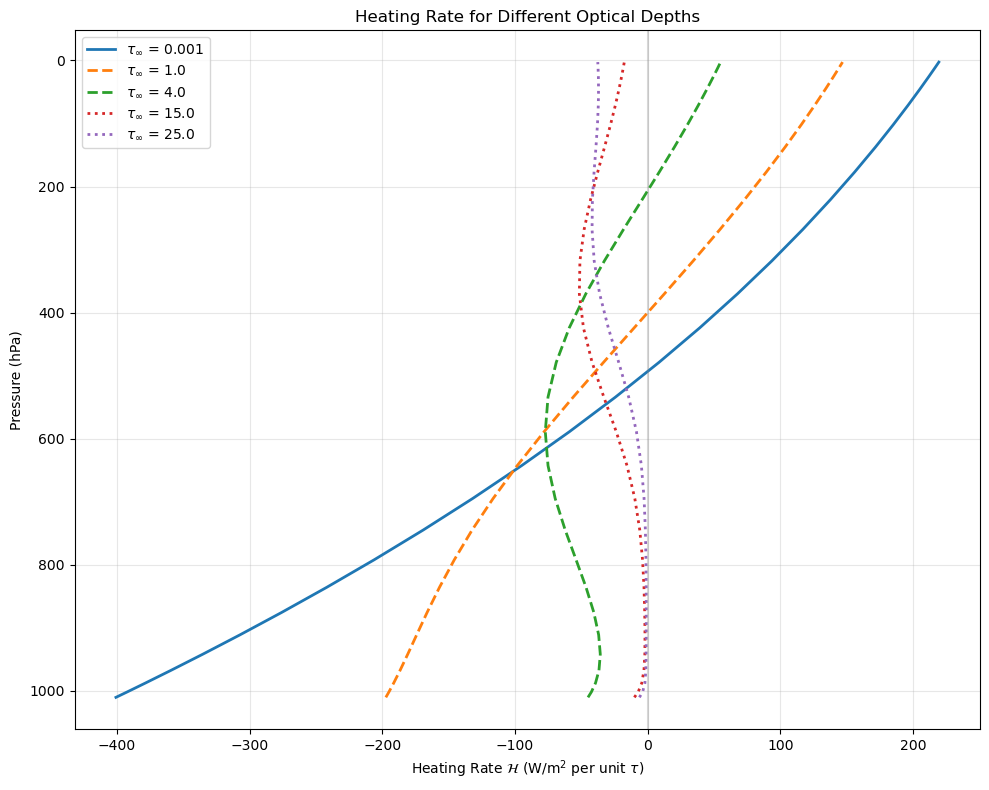

In [15]:
def compute_heating_rate(tau0):
    """Compute the heating rate profile for a given optical depth."""
    diagnostic = Frierson06LongwaveOpticalDepth(
        longwave_optical_depth_at_equator=tau0)
    radiation = GrayLongwaveRadiation()
    state = get_default_state([radiation, diagnostic])

    # Same lapse rate profile as before
    p_mid = state['air_pressure'].values.flatten()
    p_sfc, p_top = p_mid[-1], p_mid[0]
    T_profile = 200. + 90. * (p_mid - p_top) / (p_sfc - p_top)

    state['air_temperature'].values[:, 0, 0] = T_profile[::-1]
    state['surface_temperature'][:] = 290.0

    state.update(diagnostic(state))
    tendencies, diag_lw = radiation(state)
    state.update(diag_lw)

    I_up = state['upwelling_longwave_flux_in_air'].values[:, 0, 0]
    I_down = state['downwelling_longwave_flux_in_air'].values[:, 0, 0]
    I_up_mid = 0.5 * (I_up[:-1] + I_up[1:])
    I_down_mid = 0.5 * (I_down[:-1] + I_down[1:])
    T = state['air_temperature'].values.flatten()
    B = sigma * T**4
    H = I_up_mid + I_down_mid - 2 * B
    return p_mid, H

fig, ax = plt.subplots(figsize=(10, 8))
for tau0, ls in [(0.001, '-'), (1.0, '--'), (4.0, '--'), (15.0, ':'), (25.0, ':')]:
    p, H = compute_heating_rate(tau0)
    ax.plot(H, p / 100, ls, linewidth=2, label=r'$\tau_\infty$ = {}'.format(tau0))

ax.axvline(0, color='gray', linestyle='-', alpha=0.3)
ax.invert_yaxis()
ax.set_xlabel(r'Heating Rate $\mathcal{H}$ (W/m$^2$ per unit $\tau$)')
ax.set_ylabel('Pressure (hPa)')
ax.set_title('Heating Rate for Different Optical Depths')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

## Exercises:

1. What happens to the heating rate profile as you increase $\tau_\infty$ from 0.1 to 20? At what optical depth does the interior become approximately in radiative balance ($\mathcal{H} \approx 0$)?

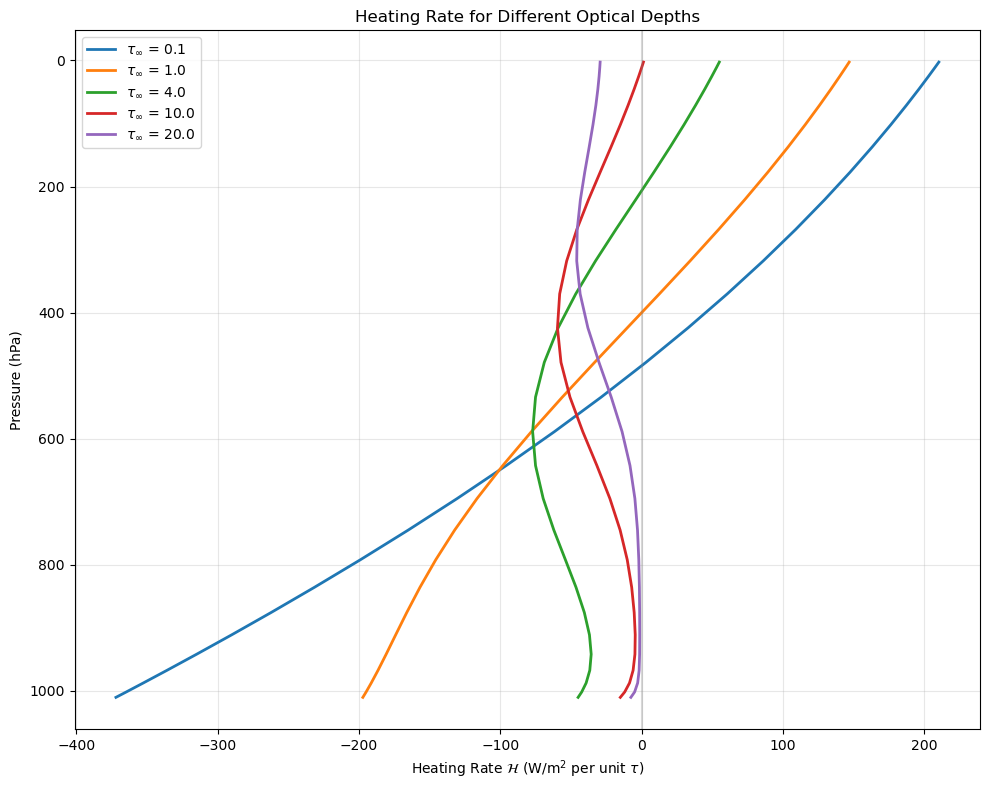

In [17]:
def compute_heating_rate(tau0):
    """Compute the heating rate profile for a given optical depth."""
    diagnostic = Frierson06LongwaveOpticalDepth(
        longwave_optical_depth_at_equator=tau0)
    radiation = GrayLongwaveRadiation()
    state = get_default_state([radiation, diagnostic])

    # Same lapse rate profile as before
    p_mid = state['air_pressure'].values.flatten()
    p_sfc, p_top = p_mid[-1], p_mid[0]
    T_profile = 200. + 90. * (p_mid - p_top) / (p_sfc - p_top)

    state['air_temperature'].values[:, 0, 0] = T_profile[::-1]
    state['surface_temperature'][:] = 290.0

    state.update(diagnostic(state))
    tendencies, diag_lw = radiation(state)
    state.update(diag_lw)

    I_up = state['upwelling_longwave_flux_in_air'].values[:, 0, 0]
    I_down = state['downwelling_longwave_flux_in_air'].values[:, 0, 0]
    I_up_mid = 0.5 * (I_up[:-1] + I_up[1:])
    I_down_mid = 0.5 * (I_down[:-1] + I_down[1:])
    T = state['air_temperature'].values.flatten()
    B = sigma * T**4
    H = I_up_mid + I_down_mid - 2 * B
    return p_mid, H

fig, ax = plt.subplots(figsize=(10, 8))
tau_arr = [0.1, 1.0, 4.0, 10.0, 20.0]
for tau0 in tau_arr:
    p, H = compute_heating_rate(tau0)
    ax.plot(H, p / 100, linewidth=2, label=r'$\tau_\infty$ = {}'.format(tau0))

ax.axvline(0, color='gray', linestyle='-', alpha=0.3)
ax.invert_yaxis()
ax.set_xlabel(r'Heating Rate $\mathcal{H}$ (W/m$^2$ per unit $\tau$)')
ax.set_ylabel('Pressure (hPa)')
ax.set_title('Heating Rate for Different Optical Depths')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

2. Change the initial temperature profile to isothermal (e.g., $T = 250$ K everywhere, including the surface). Where does the atmosphere still show non-zero heating rates? What does this tell you about boundary effects?

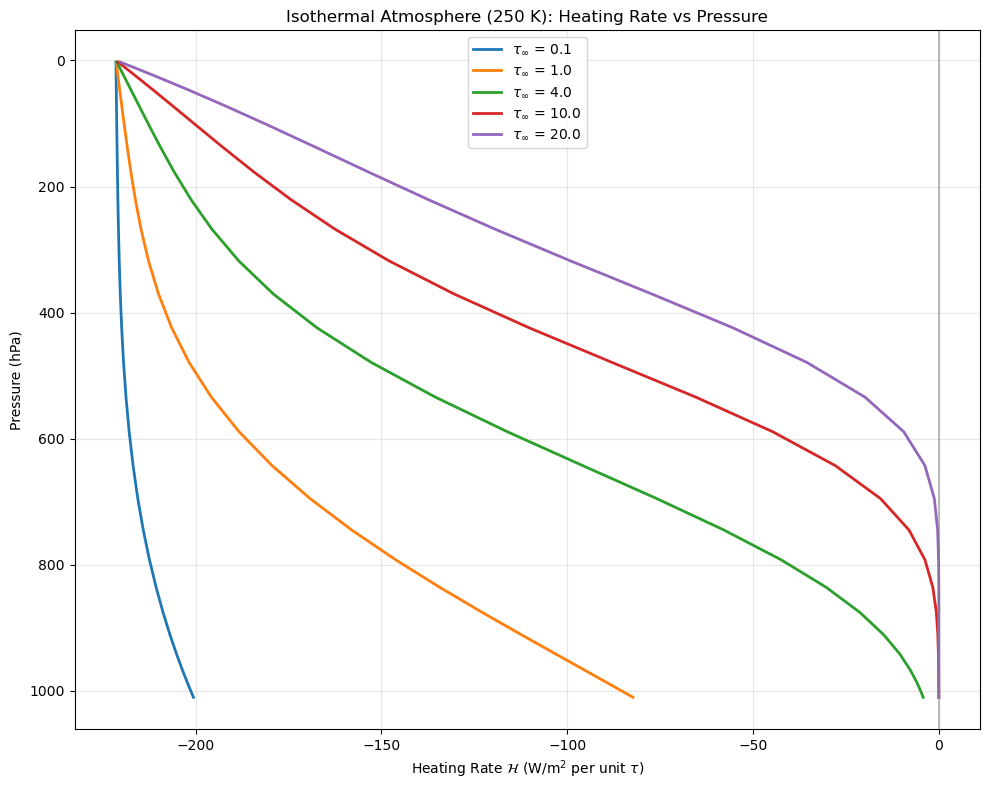

In [ ]:
def compute_heating_rate_isothermal(tau0):
    """Compute the heating rate profile for an ISOTHERMAL optical depth."""
    diagnostic = Frierson06LongwaveOpticalDepth(
        longwave_optical_depth_at_equator=tau0)
    radiation = GrayLongwaveRadiation()
    state = get_default_state([radiation, diagnostic])

    p_mid = state['air_pressure'].values.flatten()

    # Set a constant 250 K profile everywhere
    T_profile = np.ones_like(p_mid) * 250.0

    state['air_temperature'].values[:, 0, 0] = T_profile
    # Match the surface exactly to the air temperature
    state['surface_temperature'][:] = 250.0

    state.update(diagnostic(state))
    tendencies, diag_lw = radiation(state)
    state.update(diag_lw)

    I_up = state['upwelling_longwave_flux_in_air'].values[:, 0, 0]
    I_down = state['downwelling_longwave_flux_in_air'].values[:, 0, 0]
    I_up_mid = 0.5 * (I_up[:-1] + I_up[1:])
    I_down_mid = 0.5 * (I_down[:-1] + I_down[1:])
    
    T = state['air_temperature'].values.flatten()
    B = sigma * T**4
    
    H = I_up_mid + I_down_mid - 2 * B
    return p_mid, H

# Plotting
fig, ax = plt.subplots(figsize=(10, 8))
tau_arr = [0.1, 1.0, 4.0, 10.0, 20.0] 

for tau0 in tau_arr:
    p, H = compute_heating_rate_isothermal(tau0)
    ax.plot(H, p / 100, linewidth=2, label=r'$\tau_\infty$ = {}'.format(tau0))

ax.axvline(0, color='gray', linestyle='-', alpha=0.5)
ax.invert_yaxis()
ax.set_xlabel(r'Heating Rate $\mathcal{H}$ (W/m$^2$ per unit $\tau$)')
ax.set_ylabel('Pressure (hPa)')
ax.set_title('Isothermal Atmosphere (250 K): Heating Rate vs Pressure')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

3. Try switching from a linear ($f=1$) to a quadratic ($f=0$) optical depth profile while keeping $\tau_\infty = 4$. How does the shape of the heating rate profile change? Which profile concentrates more heating near the surface?

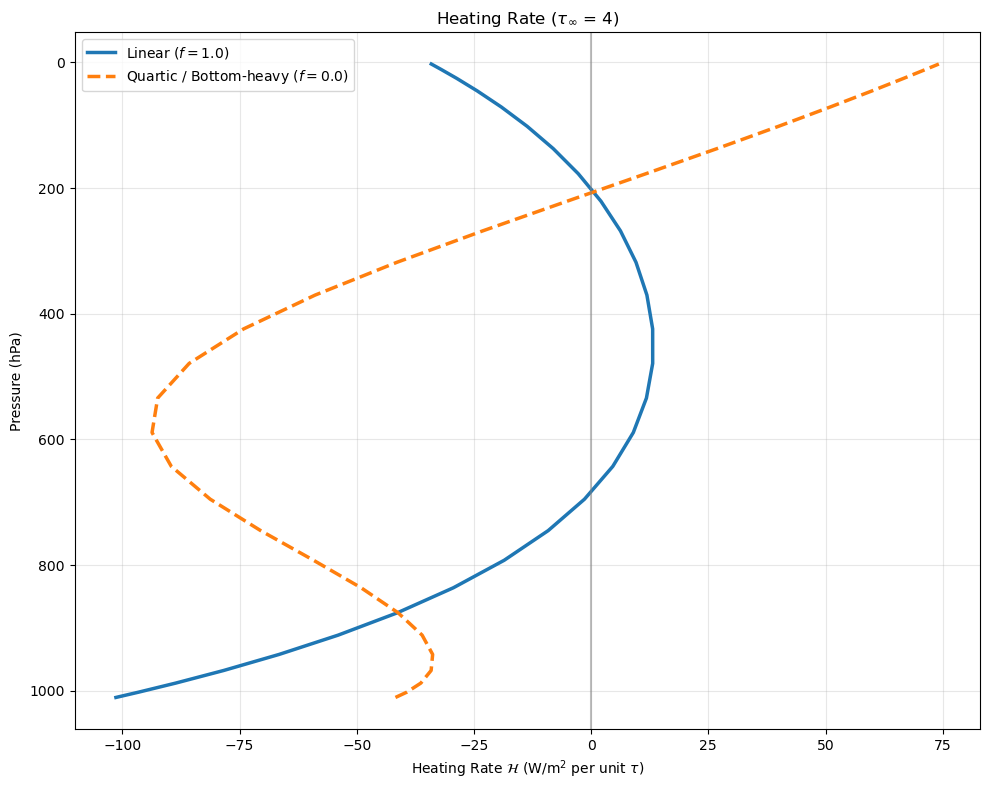

In [24]:
def compute_heating_rate_f_compare(tau0, f_val):
    """Compute the heating rate profile for a specific linear parameter f."""
    # Explicitly pass f_val to see the difference
    diagnostic = Frierson06LongwaveOpticalDepth(
        longwave_optical_depth_at_equator=tau0,
        linear_optical_depth_parameter=f_val)
    
    radiation = GrayLongwaveRadiation()
    state = get_default_state([radiation, diagnostic])

    p_mid = state['air_pressure'].values.flatten()
    p_sfc = p_mid.max()
    p_top = p_mid.min()

    T_profile = 200. + 90. * (p_mid - p_top) / (p_sfc - p_top)
    state['air_temperature'].values[:, 0, 0] = T_profile
    state['surface_temperature'][:] = 290.0

    state.update(diagnostic(state))
    tendencies, diag_lw = radiation(state)
    state.update(diag_lw)

    I_up = state['upwelling_longwave_flux_in_air'].values[:, 0, 0]
    I_down = state['downwelling_longwave_flux_in_air'].values[:, 0, 0]
    I_up_mid = 0.5 * (I_up[:-1] + I_up[1:])
    I_down_mid = 0.5 * (I_down[:-1] + I_down[1:])

    T = state['air_temperature'].values.flatten()
    B = sigma * T**4

    H = I_up_mid + I_down_mid - 2 * B
    return p_mid, H

fig, ax = plt.subplots(figsize=(10, 8))

# Calculate both profiles with tau = 4.0
p_linear, H_linear = compute_heating_rate_f_compare(tau0=4.0, f_val=1.0)
p_quartic, H_quartic = compute_heating_rate_f_compare(tau0=4.0, f_val=0.0)

# Plot them together
ax.plot(H_linear, p_linear / 100, linewidth=2.5, label=r'Linear ($f = 1.0$)')
ax.plot(H_quartic, p_quartic / 100, linewidth=2.5, linestyle='--', label=r'Quartic / Bottom-heavy ($f = 0.0$)')

ax.axvline(0, color='gray', linestyle='-', alpha=0.5)
ax.invert_yaxis()
ax.set_xlabel(r'Heating Rate $\mathcal{H}$ (W/m$^2$ per unit $\tau$)')
ax.set_ylabel('Pressure (hPa)')
ax.set_title(r'Heating Rate ($\tau_\infty$ = 4)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()